In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
warnings.filterwarnings("ignore")

In [118]:
def split_train_test(x, y, train_size=0.8, random_state=42):
    train_set_size = int(len(x) * train_size)
    
    np.random.seed(random_state)
    shuffled_indices = np.random.permutation(len(x))
        
    train_indices = shuffled_indices[:train_set_size]
    test_indices = shuffled_indices[train_set_size:]
    
    return x.iloc[train_indices], x.iloc[test_indices], y.iloc[train_indices], y.iloc[test_indices]

## Data Transformation

In [119]:
cancer_data = pd.read_csv("./input/breast_cancer.csv")
cancer_data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [120]:
cancer_data = cancer_data.drop(columns=["id"])

In [121]:
x_train, x_test, y_train, y_test = split_train_test(cancer_data.drop("diagnosis", axis=1), cancer_data["diagnosis"])
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((455, 30), (114, 30), (455,), (114,))

In [122]:
def z_score(x):
    return (x - x.mean()) / x.std(ddof=1)

In [123]:
x_train = z_score(x_train)
x_test = z_score(x_test)

In [124]:
x_train.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,...,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02,4.550000e+02
mean,1.913000e-16,2.986622e-16,1.561632e-17,-2.498612e-16,3.201346e-16,2.615734e-16,3.318469e-17,9.369794e-17,7.691040e-16,1.223929e-15,...,1.483551e-16,1.346908e-16,1.132183e-16,-1.542112e-16,-1.717796e-16,3.318469e-17,-5.172907e-17,4.782499e-17,5.075305e-17,6.754060e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-2.030812e+00,-2.129571e+00,-1.983912e+00,-1.483880e+00,-3.132733e+00,-1.597420e+00,-1.104648e+00,-1.248975e+00,-2.671519e+00,-1.846342e+00,...,-1.720164e+00,-2.220039e+00,-1.684319e+00,-1.238335e+00,-2.706369e+00,-1.470092e+00,-1.299576e+00,-1.728696e+00,-2.139142e+00,-1.621388e+00
25%,-7.001444e-01,-7.096726e-01,-6.991214e-01,-6.871423e-01,-7.057065e-01,-7.152109e-01,-7.377308e-01,-7.264473e-01,-6.896373e-01,-6.839850e-01,...,-6.993555e-01,-7.210048e-01,-6.945091e-01,-6.563954e-01,-6.935686e-01,-6.866667e-01,-7.402734e-01,-7.470307e-01,-6.440659e-01,-6.801355e-01
50%,-2.048052e-01,-1.052324e-01,-2.294106e-01,-2.967290e-01,5.298664e-03,-2.569265e-01,-3.434784e-01,-3.922714e-01,-1.129930e-01,-1.712429e-01,...,-2.669150e-01,-4.815722e-02,-2.765626e-01,-3.412980e-01,-4.670777e-02,-2.539779e-01,-2.128764e-01,-2.362788e-01,-1.234520e-01,-2.141162e-01
75%,4.872339e-01,5.671627e-01,5.074885e-01,3.834741e-01,6.227222e-01,4.804479e-01,5.267843e-01,6.401922e-01,4.831685e-01,4.861733e-01,...,5.397528e-01,5.844703e-01,5.459202e-01,3.836059e-01,6.001531e-01,5.371323e-01,5.371465e-01,7.163443e-01,4.535948e-01,4.465198e-01
max,3.780881e+00,4.761286e+00,3.767809e+00,4.722954e+00,3.469611e+00,4.507172e+00,4.198438e+00,3.921052e+00,4.354670e+00,4.888096e+00,...,3.519018e+00,3.590079e+00,3.646621e+00,4.607711e+00,4.002818e+00,5.186277e+00,4.662510e+00,2.696097e+00,5.925207e+00,6.892608e+00


## Data Exploration Visualizations

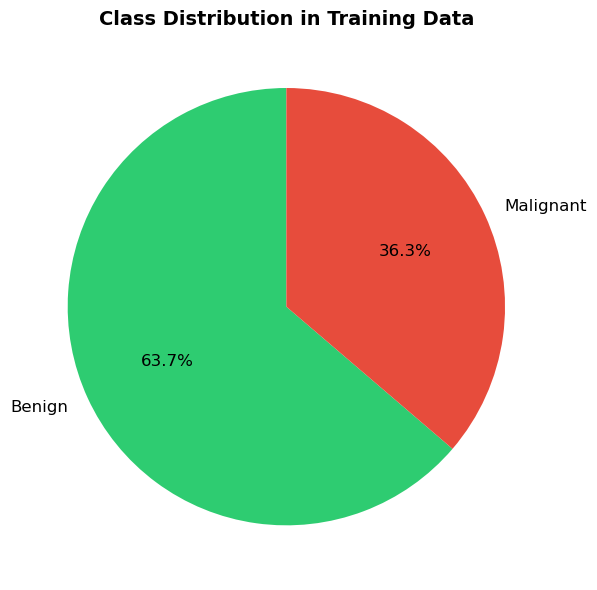

Benign: 165 (36.3%)
Malignant: 290 (63.7%)


In [125]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

benign_counts = y_train.value_counts()
labels = ["Benign", "Malignant"]
colors = ["#2ecc71", "#e74c3c"]

ax.pie(benign_counts.values, labels=labels, autopct="%1.1f%%", 
       colors=colors, startangle=90, textprops={"fontsize": 12})
ax.set_title("Class Distribution in Training Data", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Benign: {benign_counts[1]} ({benign_counts[1]/len(y_train)*100:.1f}%)")
print(f"Malignant: {benign_counts[0]} ({benign_counts[0]/len(y_train)*100:.1f}%)")

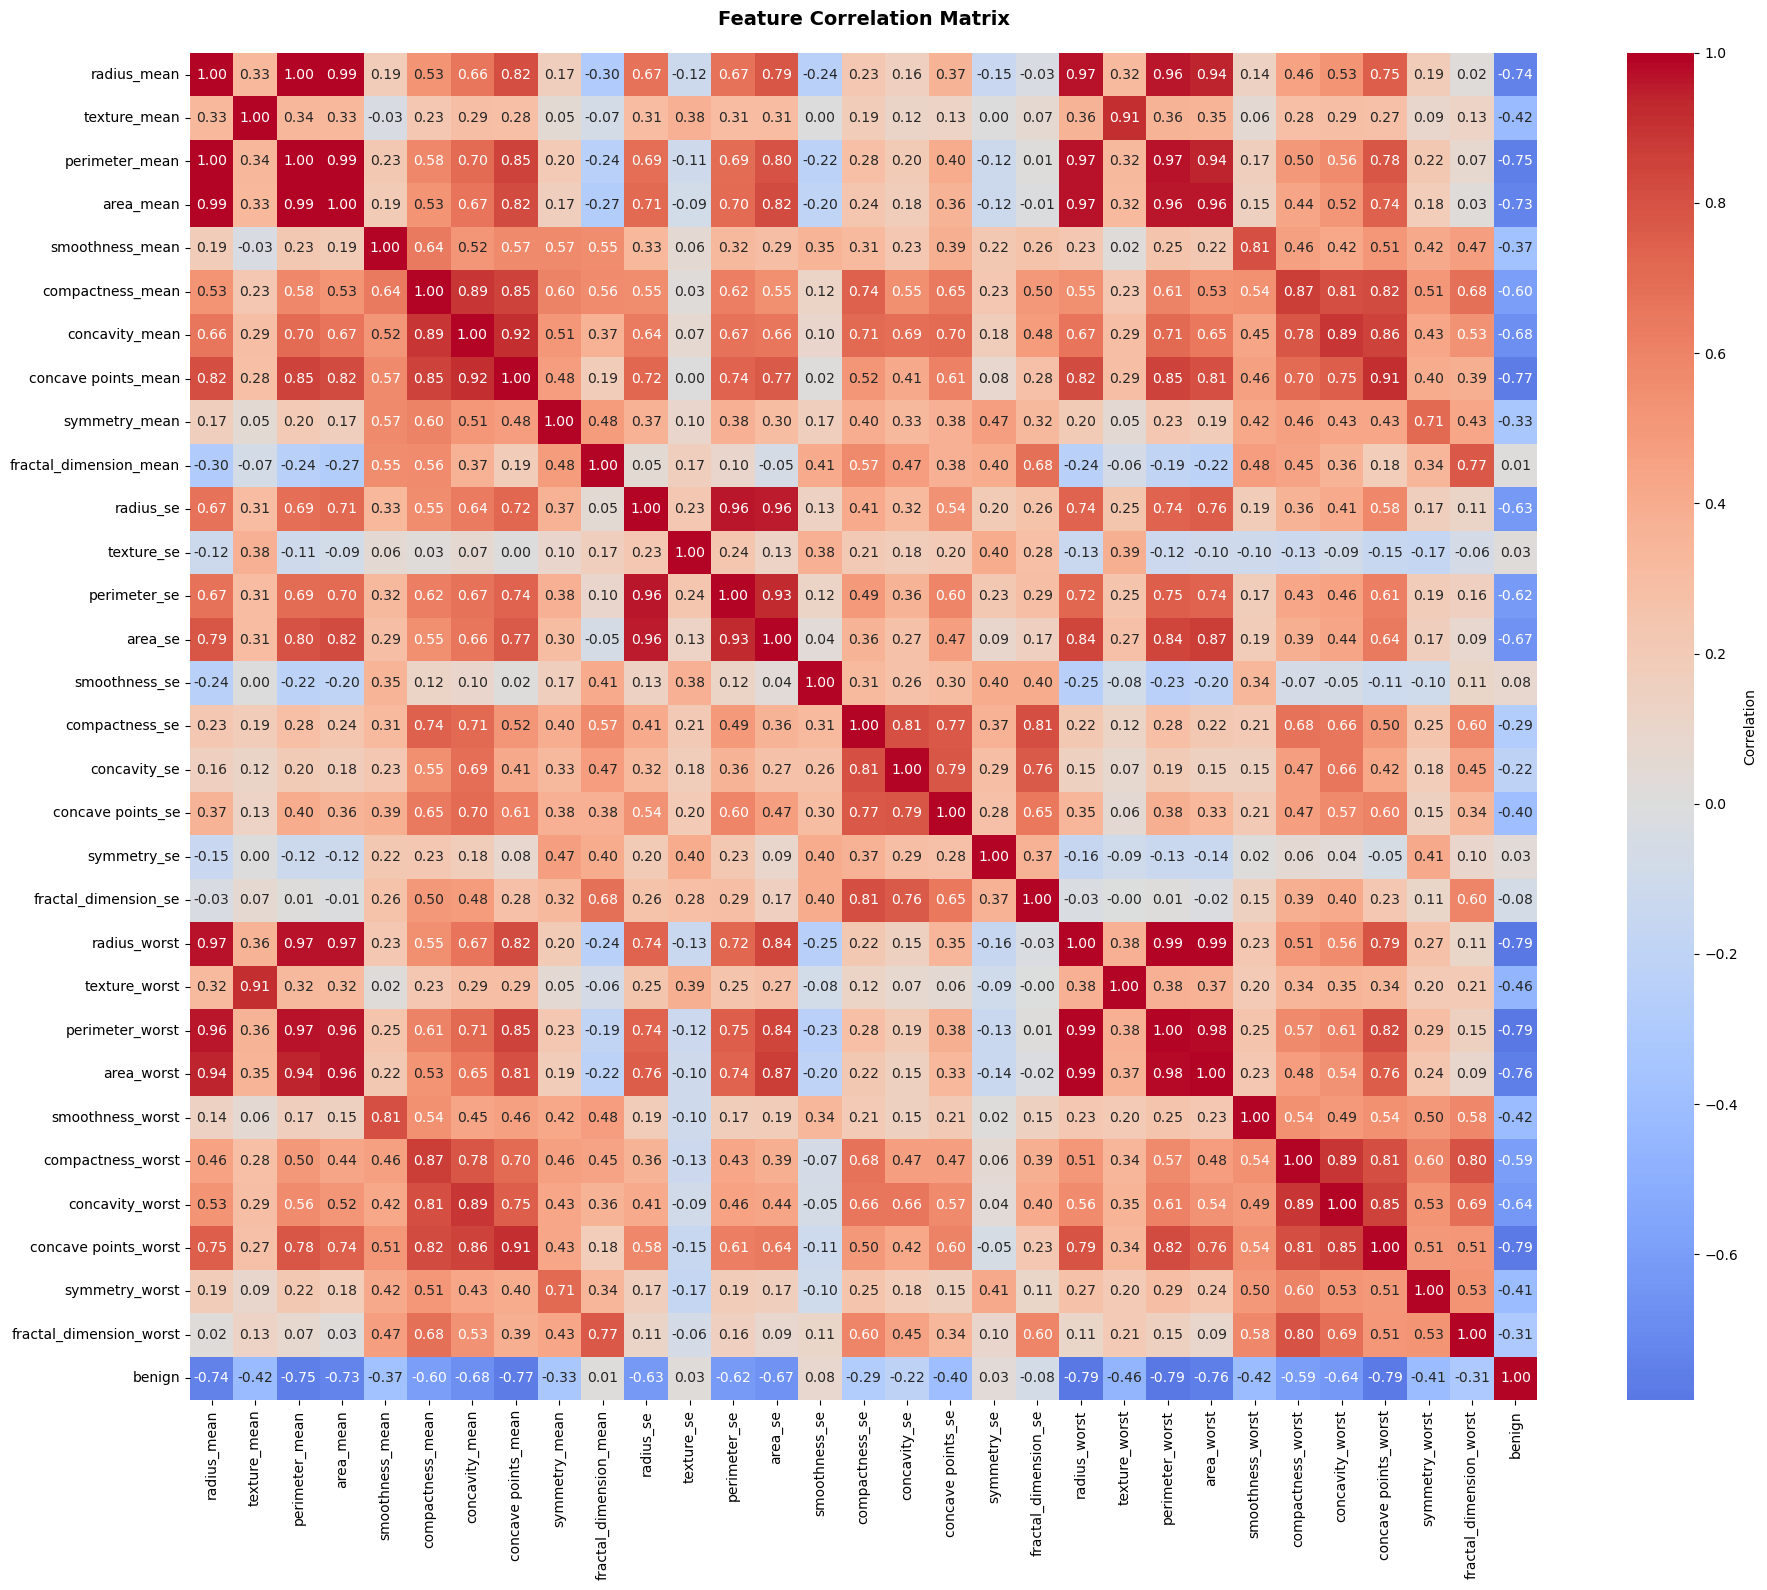

In [126]:
fig, ax = plt.subplots(figsize=(20, 16))

correlation_data = x_train.copy()
correlation_data["benign"] = y_train.replace({"B": 1, "M": 0})

correlation_matrix = correlation_data.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            center=0, square=True, ax=ax, cbar_kws={"label": "Correlation"})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

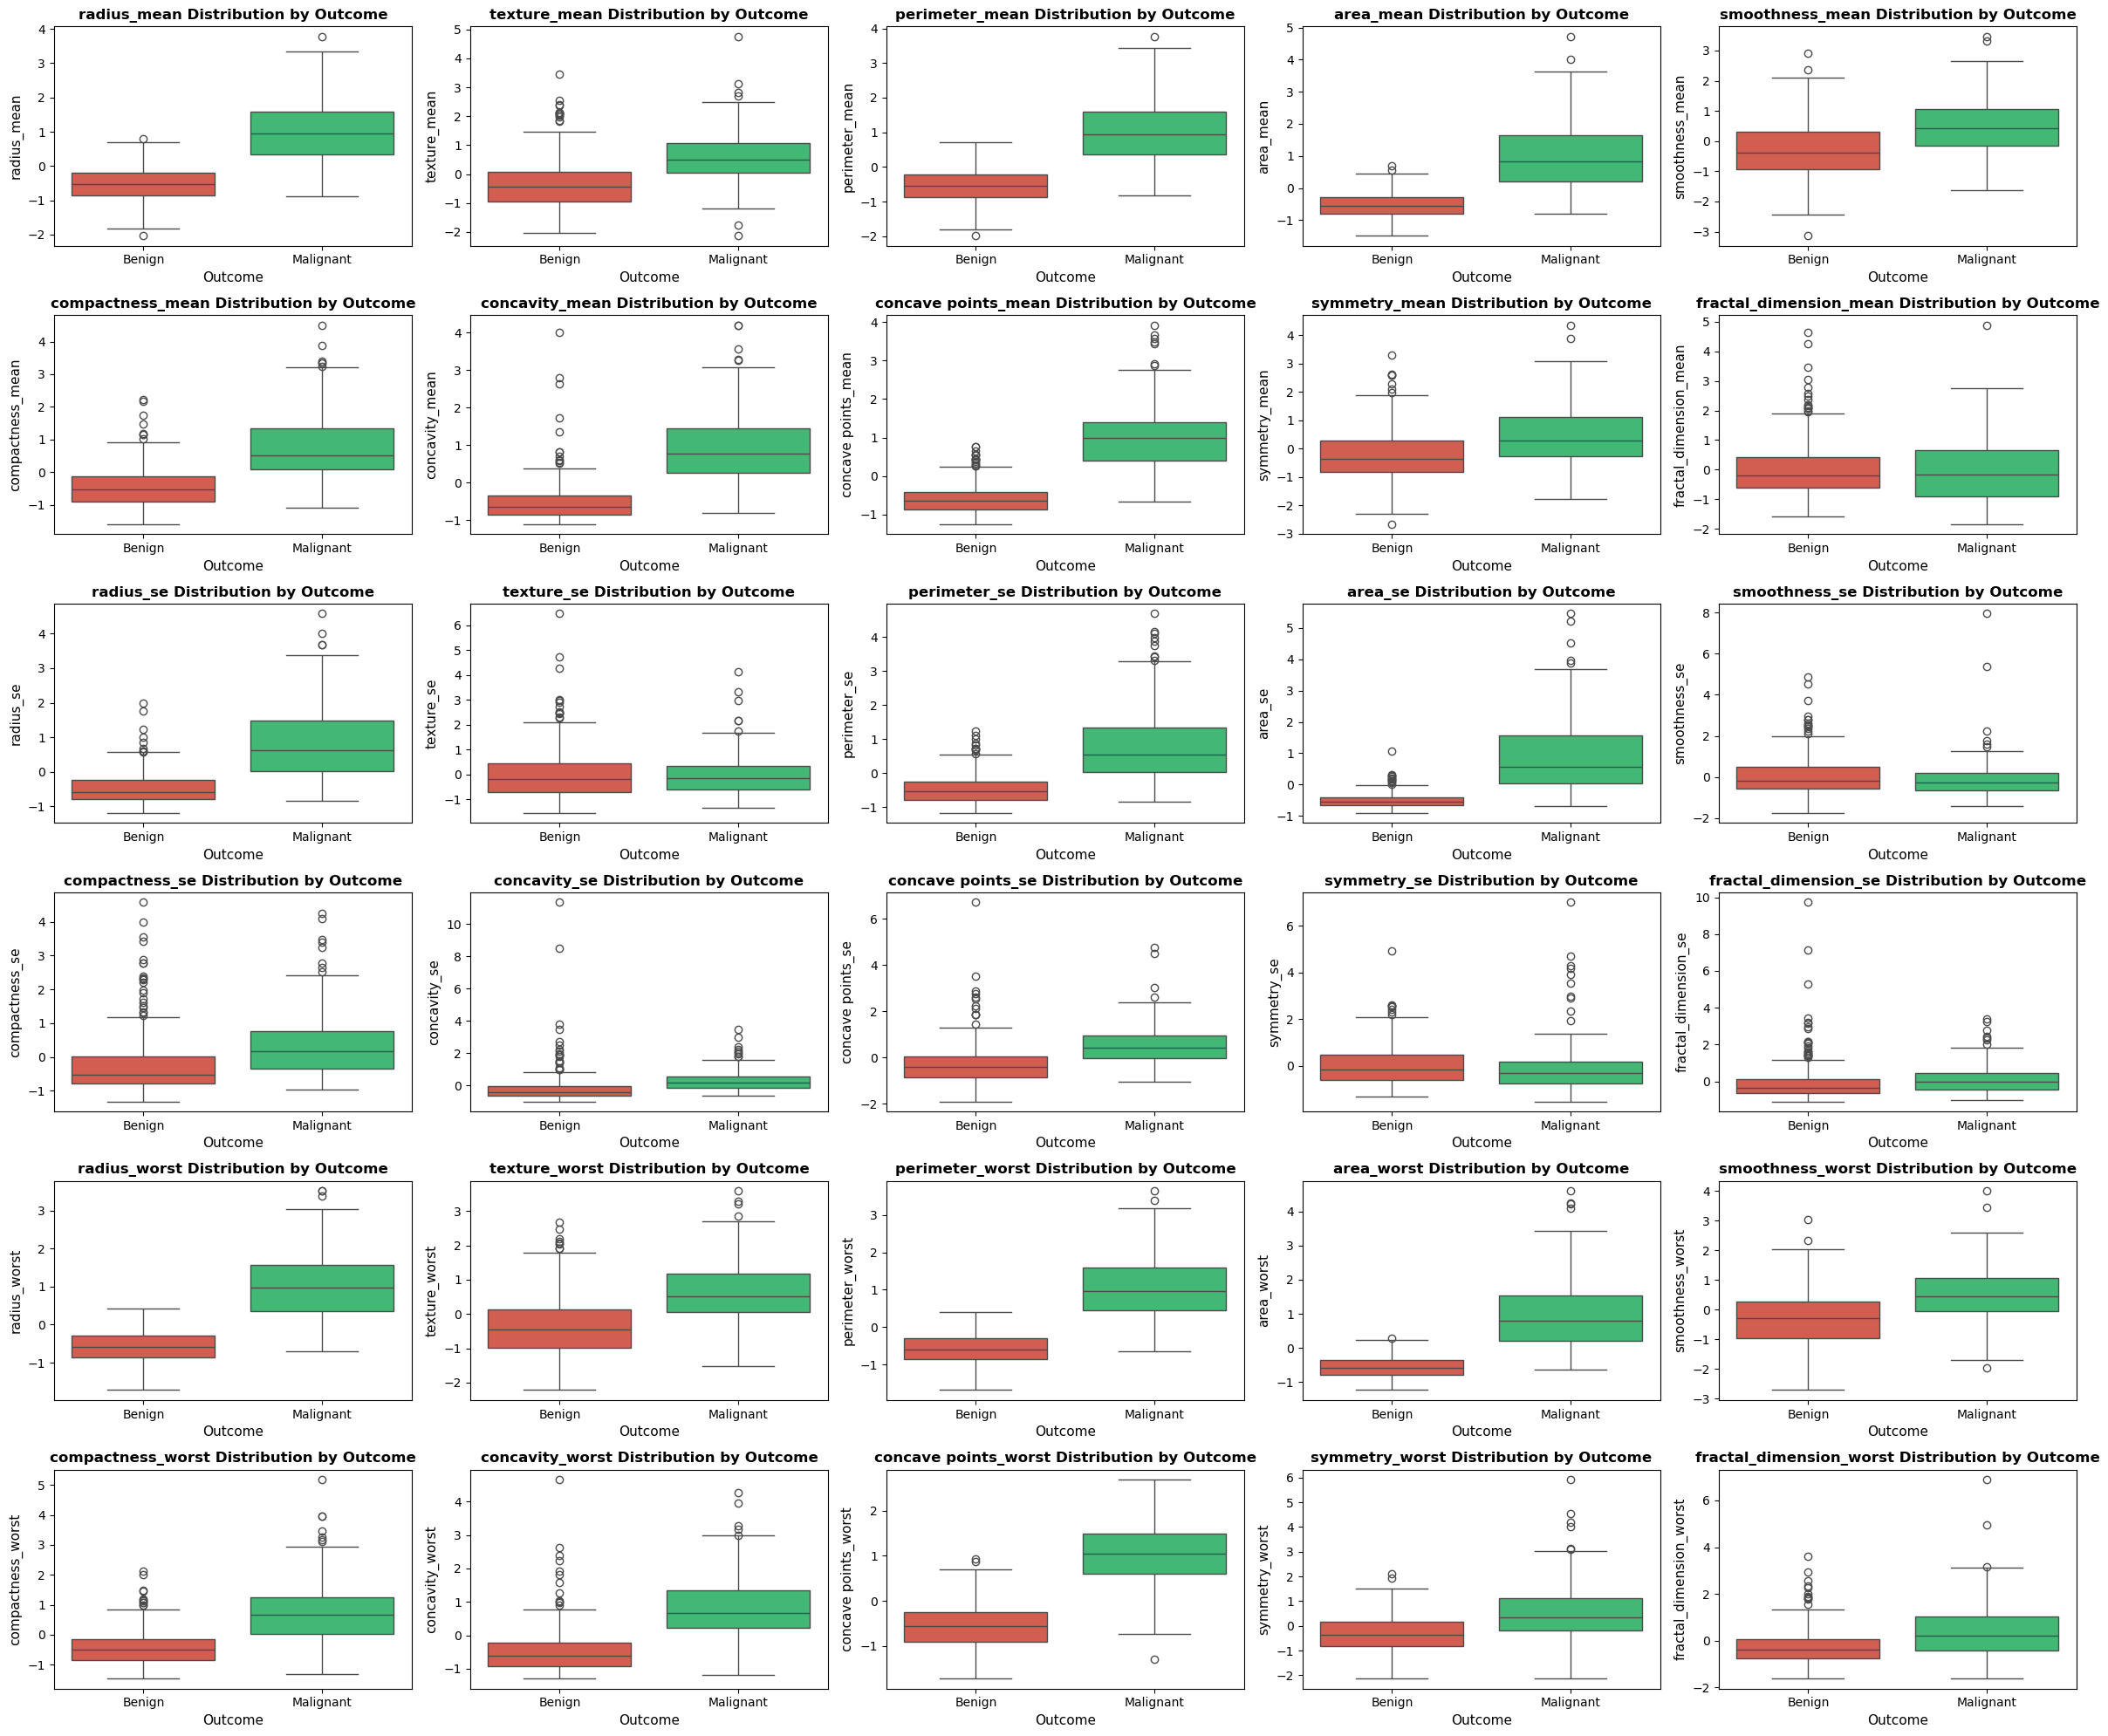

In [127]:
fig, axes = plt.subplots(6, 5, figsize=(24, 20))
axes = axes.ravel()

viz_data = x_train.copy()
viz_data["Outcome"] = y_train.replace({"B": "Benign", "M": "Malignant"})

for idx, feature in enumerate(x_train.columns):
    sns.boxplot(data=viz_data, x="Outcome", y=feature, ax=axes[idx], 
                palette=["#e74c3c", "#2ecc71"])
    axes[idx].set_title(f"{feature} Distribution by Outcome", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Outcome", fontsize=11)
    axes[idx].set_ylabel(feature, fontsize=11)

plt.tight_layout()
plt.show()

## Model Building

In [128]:
x_train = np.array(x_train)
x_test = np.array(x_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [129]:
def predict(x, k=5):
    distances = []
    
    for i in range (len(x_train)):
        distances.append({"idx": i, "dist": math.dist(x, x_train[i])})
    
    distances = sorted(distances, key=lambda d: d["dist"])
    neighbors = distances[:k]
    
    neighbor_indices = [neighbor["idx"] for neighbor in neighbors]
    neighbor_labels = y_train[neighbor_indices]
    
    values, counts = np.unique(neighbor_labels, return_counts=True)
    
    return values[np.argmax(counts)]

## Model Evaluation

In [130]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

In [131]:
predictions = []

for x in x_test:
    prediction = predict(x, 4)
    predictions.append(prediction)

predictions = np.array(predictions)

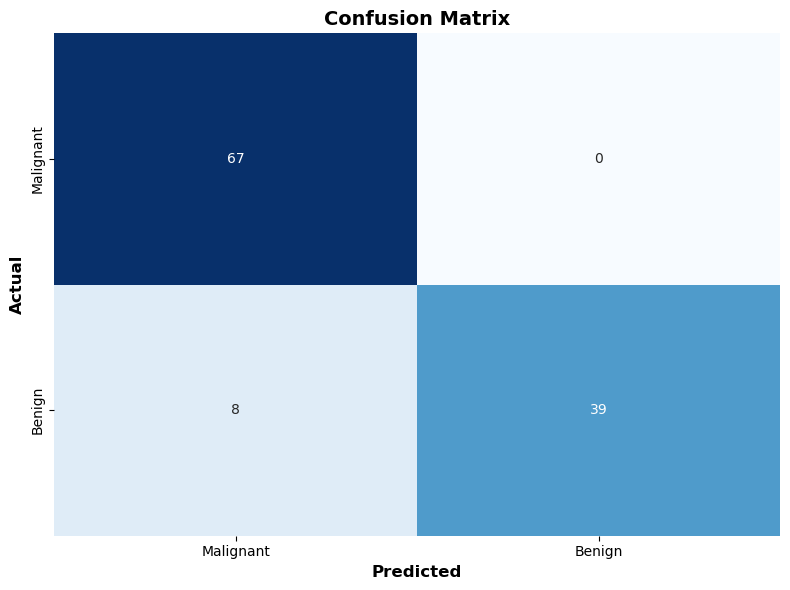

True Negatives: 67
False Positives: 0
False Negatives: 8
True Positives: 39

Sensitivity (Recall): 0.8298
Specificity: 1.0000
Precision: 1.0000


In [132]:
cm = confusion_matrix(y_test, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Malignant", "Benign"], yticklabels=["Malignant", "Benign"])
ax.set_xlabel("Predicted", fontsize=12, fontweight="bold")
ax.set_ylabel("Actual", fontsize=12, fontweight="bold")
ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

tn_val, fp_val, fn_val, tp_val = cm.ravel()
sensitivity = tp_val / (tp_val + fn_val)
specificity = tn_val / (tn_val + fp_val)
precision = tp_val / (tp_val + fp_val)

print(f"True Negatives: {tn_val}")
print(f"False Positives: {fp_val}")
print(f"False Negatives: {fn_val}")
print(f"True Positives: {tp_val}")
print(f"\nSensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")

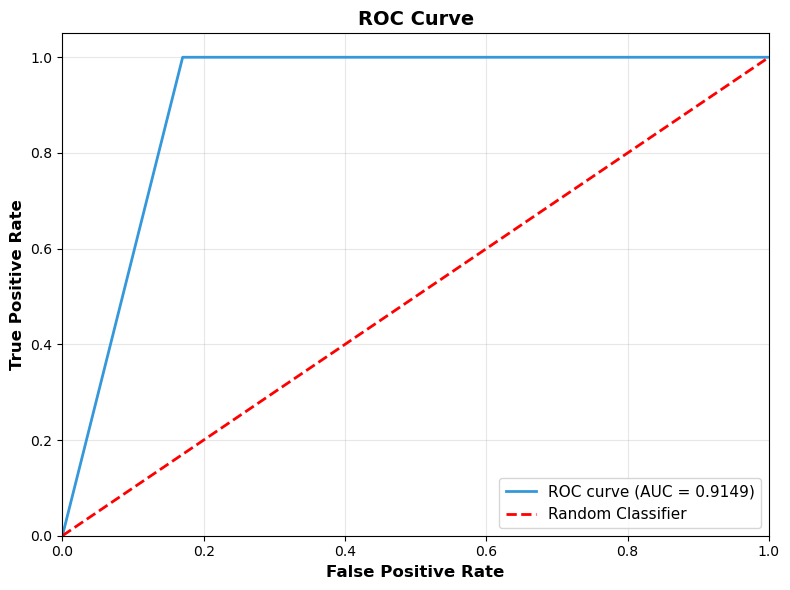

Area Under the Curve (AUC): 0.9149


In [133]:
mapping = {"B": 1, "M": 0}
y_test_int = np.vectorize(mapping.get)(y_test)
predictions_int = np.vectorize(mapping.get)(predictions)

fpr, tpr, thresholds = roc_curve(y_test_int, predictions_int)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="#3498db", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random Classifier")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12, fontweight="bold")
ax.set_ylabel("True Positive Rate", fontsize=12, fontweight="bold")
ax.set_title("ROC Curve", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Area Under the Curve (AUC): {roc_auc:.4f}")